# `SoftHarmonic` bond & `SoftHarmonicAngle` — demo

These forces are **harmonic near equilibrium but saturate in the tail**, chosen
per type via `tail`:

* `tail="linear"` (Huber) — exactly harmonic up to a crossover `x_c`, then a
  **constant** restoring force/torque `k·x_c` (capped, never releases).
* `tail="flat"` — the restoring force decays smoothly to **zero** at `x_c` and
  stays zero beyond it (a soft/breakable bond, or a free hinge past a threshold).

This notebook reads energies and forces **straight from the compiled force**
(not analytics), and then shows the dynamical payoff: a chain started far past
`x_c` stays finite. Analytic landscapes for all six plugin forces live in
[`../energy_landscapes.ipynb`](../energy_landscapes.ipynb).

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import hoomd
from hoomd import align_angle

dev = hoomd.device.auto_select()
print("HOOMD", hoomd.version.version, "| device:", type(dev).__name__,
      "| precision", hoomd.version.floating_point_precision)

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.grid": True,
                     "grid.alpha": 0.3, "lines.linewidth": 2.0})


def bond_scan(r_values, make_force, direction=(1.0, 0.3, -0.2)):
    """Two bonded particles: sweep separation, read energy & radial force."""
    u = np.array(direction, float); u /= np.linalg.norm(u)
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [50, 50, 50, 0, 0, 0]
        snap.particles.N = 2
        snap.particles.types = ["A"]
        snap.particles.position[:] = [[0, 0, 0], (r_values[0] * u).tolist()]
        snap.bonds.N = 1; snap.bonds.types = ["A-A"]
        snap.bonds.typeid[0] = 0; snap.bonds.group[0] = (0, 1)
    sim = hoomd.Simulation(device=dev)
    sim.create_state_from_snapshot(snap)
    force = make_force()
    sim.operations.integrator = hoomd.md.Integrator(dt=0.0, forces=[force])
    sim.run(0)
    U, F = [], []
    for r in r_values:
        s = sim.state.get_snapshot()
        if s.communicator.rank == 0:
            s.particles.position[1] = r * u
        sim.state.set_snapshot(s)
        sim.run(0)
        U.append(force.energy)
        F.append(float(np.dot(np.array(force.forces[1]), u)))  # radial force on particle 1
    return np.array(U), np.array(F)


def run_chain(tail, N=20, spacing=2.5, k=100.0, r0=1.0, x_c=0.3,
              dt=0.005, steps=3000, sample=100):
    """20-bead chain started far past x_c; Langevin; track total bond energy."""
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [200, 200, 200, 0, 0, 0]
        snap.particles.N = N
        snap.particles.types = ["A"]
        pos = np.zeros((N, 3)); pos[:, 0] = (np.arange(N) - (N - 1) / 2) * spacing
        snap.particles.position[:] = pos
        snap.bonds.N = N - 1; snap.bonds.types = ["A-A"]
        snap.bonds.group[:] = [[i, i + 1] for i in range(N - 1)]
    sim = hoomd.Simulation(device=dev, seed=1)
    sim.create_state_from_snapshot(snap)
    bond = align_angle.SoftHarmonic()
    bond.params["A-A"] = dict(k=k, r0=r0, x_c=x_c, tail=tail)
    lang = hoomd.md.methods.Langevin(filter=hoomd.filter.All(), kT=1.0)
    sim.operations.integrator = hoomd.md.Integrator(dt=dt, methods=[lang], forces=[bond])
    sim.run(0)
    ts, es = [0], [bond.energy]
    for _ in range(steps // sample):
        sim.run(sample)
        ts.append(sim.timestep); es.append(bond.energy)
    return np.array(ts), np.array(es)


def angle_scan(theta_values, make_force):
    """Three particles a-b-c (b vertex): sweep the vertex angle, read energy."""
    snap = hoomd.Snapshot(dev.communicator)
    if snap.communicator.rank == 0:
        snap.configuration.box = [50, 50, 50, 0, 0, 0]
        snap.particles.N = 3
        snap.particles.types = ["A"]
        snap.particles.position[:] = [[1, 0, 0], [0, 0, 0], [1, 0, 0]]
        snap.angles.N = 1; snap.angles.types = ["A-A-A"]
        snap.angles.typeid[0] = 0; snap.angles.group[0] = (0, 1, 2)
    sim = hoomd.Simulation(device=dev)
    sim.create_state_from_snapshot(snap)
    force = make_force()
    sim.operations.integrator = hoomd.md.Integrator(dt=0.0, forces=[force])
    sim.run(0)
    U = []
    for th in theta_values:
        s = sim.state.get_snapshot()
        if s.communicator.rank == 0:
            s.particles.position[0] = [1.0, 0.0, 0.0]
            s.particles.position[2] = [np.cos(th), np.sin(th), 0.0]
        sim.state.set_snapshot(s)
        sim.run(0)
        U.append(force.energy)
    return np.array(U)

HOOMD 6.1.1 | device: GPU | precision (64, 32)


## 1. Bond: energy & force, measured from the compiled force

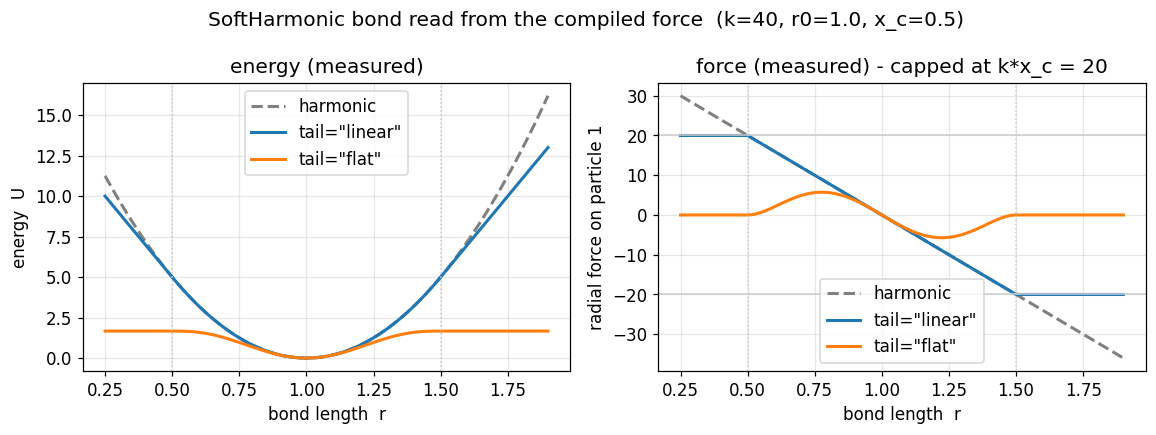

In [2]:
K, R0, XC = 40.0, 1.0, 0.5
rr = np.linspace(0.25, 1.9, 120)


def soft(tail):
    def f():
        b = align_angle.SoftHarmonic()
        b.params["A-A"] = dict(k=K, r0=R0, x_c=XC, tail=tail)
        return b
    return f


def harm():
    b = hoomd.md.bond.Harmonic()
    b.params["A-A"] = dict(k=K, r0=R0)
    return b


Uh, Fh = bond_scan(rr, harm)
Ul, Fl = bond_scan(rr, soft("linear"))
Uf, Ff = bond_scan(rr, soft("flat"))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.0))
a1.plot(rr, Uh, "--", color="0.5", label="harmonic")
a1.plot(rr, Ul, label='tail="linear"'); a1.plot(rr, Uf, label='tail="flat"')
for xv in (R0 - XC, R0 + XC):
    a1.axvline(xv, color="0.8", ls=":", lw=1)
a1.set_xlabel("bond length  r"); a1.set_ylabel("energy  U")
a1.set_title("energy (measured)"); a1.legend()

a2.plot(rr, Fh, "--", color="0.5", label="harmonic")
a2.plot(rr, Fl, label='tail="linear"'); a2.plot(rr, Ff, label='tail="flat"')
for xv in (R0 - XC, R0 + XC):
    a2.axvline(xv, color="0.8", ls=":", lw=1)
for yv in (K * XC, -K * XC):
    a2.axhline(yv, color="0.8", lw=1)
a2.set_xlabel("bond length  r"); a2.set_ylabel("radial force on particle 1")
a2.set_title("force (measured) - capped at k*x_c = %.0f" % (K * XC)); a2.legend()
fig.suptitle("SoftHarmonic bond read from the compiled force  (k=%.0f, r0=%.1f, x_c=%.1f)"
             % (K, R0, XC))
fig.tight_layout()
plt.show()

## 2. Bond: an over-stretched chain stays finite

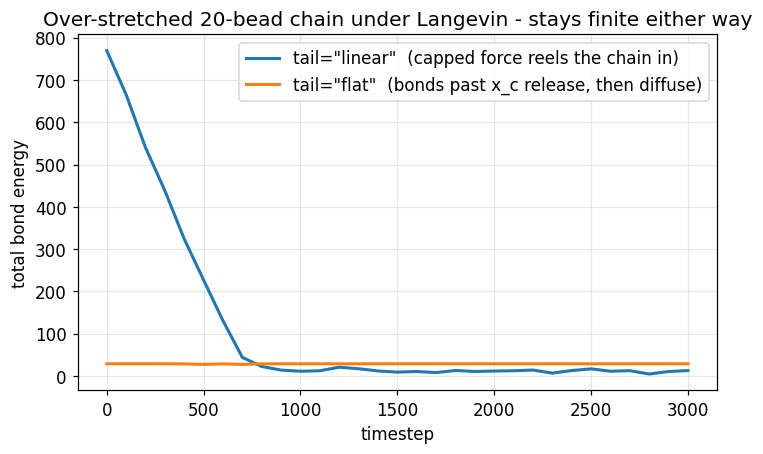

final bond energy   linear = 12.48   flat = 28.50   (both finite, no blow-up)


In [3]:
# 20-bead chain, initial spacing 2.5 (r0=1 => every bond stretched to x=1.5, far
# past x_c=0.3). With a plain harmonic bond this would launch violently; here the
# saturating tail keeps it finite.
tl, el = run_chain("linear")
tf, ef = run_chain("flat")

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(tl, el, label='tail="linear"  (capped force reels the chain in)')
ax.plot(tf, ef, label='tail="flat"  (bonds past x_c release, then diffuse)')
ax.set_xlabel("timestep"); ax.set_ylabel("total bond energy")
ax.set_title("Over-stretched 20-bead chain under Langevin - stays finite either way")
ax.legend()
plt.show()
print("final bond energy   linear = %.2f   flat = %.2f   (both finite, no blow-up)"
      % (el[-1], ef[-1]))

## 3. Angle: energy, measured from the compiled force

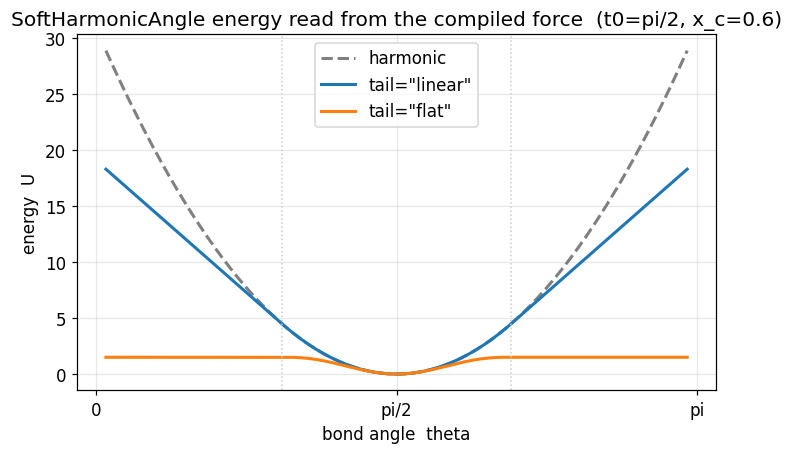

In [4]:
KA, T0, XCA = 25.0, np.pi / 2, 0.6
th = np.linspace(0.05, np.pi - 0.05, 150)


def softA(tail):
    def f():
        a = align_angle.SoftHarmonicAngle()
        a.params["A-A-A"] = dict(k=KA, t0=T0, x_c=XCA, tail=tail)
        return a
    return f


def harmA():
    a = hoomd.md.angle.Harmonic()
    a.params["A-A-A"] = dict(k=KA, t0=T0)
    return a


UhA = angle_scan(th, harmA)
UlA = angle_scan(th, softA("linear"))
UfA = angle_scan(th, softA("flat"))

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.plot(th, UhA, "--", color="0.5", label="harmonic")
ax.plot(th, UlA, label='tail="linear"'); ax.plot(th, UfA, label='tail="flat"')
for xv in (T0 - XCA, T0 + XCA):
    ax.axvline(xv, color="0.8", ls=":", lw=1)
ax.set_xticks([0, np.pi / 2, np.pi]); ax.set_xticklabels(["0", "pi/2", "pi"])
ax.set_xlabel("bond angle  theta"); ax.set_ylabel("energy  U")
ax.set_title("SoftHarmonicAngle energy read from the compiled force  (t0=pi/2, x_c=0.6)")
ax.legend()
plt.show()

**Takeaways**

* Both tails are **exactly harmonic** for small deformations (they overlap the
  dashed harmonic curve inside `x_c`), so `k` keeps its usual meaning.
* `tail="linear"` **caps** the force/torque at `k·x_c` — useful to keep stiff
  bonds/angles from blowing up under strong forcing or large time steps.
* `tail="flat"` **releases** past `x_c` (zero force/torque) — a soft, breakable
  bond or a free hinge beyond a threshold angle.